In [44]:
import joblib

import math
import re

from collections import Counter

import nltk
import pandas as pd

from nltk.util import ngrams
from nltk import pos_tag, word_tokenize
from nltk.corpus import stopwords
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, root_mean_squared_error, f1_score

In [2]:
nltk.download('punkt')
nltk.download('averaged_perceptron_tagger')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /Users/personal/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/personal/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/personal/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/personal/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/personal/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [3]:
# Calculate entropy
def calculate_entropy(freq_dict, total_count):
    return -sum((count / total_count) * math.log2(count / total_count) for count in freq_dict.values() if count > 0)

In [4]:
def calculate_features(text):
    # Tokenize the text
    try:
        words = word_tokenize(text)
    except TypeError as exc:
        print(text)
        raise exc
    
    num_words = len(words)
    num_chars = len(text)
    num_lines = text.count('\n') + 1

    # Calculate word frequency
    word_freq = Counter(words)

    # Calculate n-grams (bigrams in this example)
    bigrams = list(ngrams(words, 2))
    bigram_freq = Counter(bigrams)

    # Calculate character distribution
    char_freq = Counter(text)

    # Calculate punctuation usage
    punctuation = re.findall(r'[^\w\s]', text)
    punctuation_freq = Counter(punctuation)

    # Calculate part-of-speech tags
    pos_tags = pos_tag(words)
    pos_freq = Counter(tag for word, tag in pos_tags)

    word_entropy = calculate_entropy(word_freq, num_words)
    char_entropy = calculate_entropy(char_freq, num_chars)

    # Calculate capitalization patterns
    num_uppercase = sum(1 for c in text if c.isupper())
    num_lowercase = sum(1 for c in text if c.islower())
    capitalization_ratio = num_uppercase / num_lowercase if num_lowercase > 0 else 0

    # Compile features into a dictionary
    features = {
        'num_words': num_words,
        'num_chars': num_chars,
        'num_lines': num_lines,
        # 'word_freq': word_freq,
        # 'bigram_freq': bigram_freq,
        # 'char_freq': char_freq,
        # 'punctuation_freq': punctuation_freq,
        # 'pos_freq': pos_freq,
        'word_entropy': word_entropy,
        'char_entropy': char_entropy,
        'capitalization_ratio': capitalization_ratio
    }

    return features

## Load the original data

In [5]:
data = pd.read_excel("raw-data/halle.xlsx")
data.head()

,request-id,session,session-id,commands,true-response,generated-response,convincing
0,ed866470-ed17-443b-afe2-05b526bacdb7,13123,1,"filename=""/fuck"";($filename) || (rm -rf $filen...",Linux userdb.verwaltung.uni-halle.de 3.16.0-4-...,bash: /fuck: Permission denied\nrm: cannot rem...,0
1,ea3046f7-1a9e-48fa-97d1-8836122fe7bc,14680,1,"filename=""/fuck"";($filename) || (rm -rf $filen...",Linux userdb.verwaltung.uni-halle.de 3.16.0-4-...,bash: /fuck: No such file or directory\nbash: ...,0
2,4e3f80cd-f52b-45e5-982b-0c46ef2827a5,17949,1,"filename=""/fuck"";($filename) || (rm -rf $filen...",Linux userdb.verwaltung.uni-halle.de 3.16.0-4-...,bash: /fuck: Permission denied\n/bin/rm: missi...,0
3,e4f87d0a-5474-4bc3-9022-77e0a817e595,17950,1,"filename=""/fuck"";($filename) || (rm -rf $filen...",Linux userdb.verwaltung.uni-halle.de 3.16.0-4-...,bash: /fuck: No such file or directory\n/bin/r...,0
4,ee1e3bda-7836-44a3-9352-cc081679ee66,18183,1,"filename=""/fuck"";($filename) || (rm -rf $filen...",Linux userdb.verwaltung.uni-halle.de 3.16.0-4-...,bash: /fuck: No such file or directory\nrm: ca...,0


In [6]:
data2 = pd.read_excel("raw-data/nl2bash.xlsx")
data2.head()

,request-id,session,session-id,commands,true-response,generated-response,convincing
0,2ced1c7c-5776-4b06-89a3-3ee7afab6dcf,-1,-1,"alias rm1g=""find / -type f -name *.tar -size +...",Could not chdir to home directory /home/vagran...,bash: syntax error near unexpected token `;',0.0
1,315e545e-da03-4e88-96b0-33438f4a8c60,-1,-1,apropos disk,cfdisk (8) - display or manipulate a...,fdisk (8) - manipulate disk partiti...,0.0
2,5139a21f-99bb-40e6-a4de-9bca2b448118,-1,-1,"awk 'NR==1 {print $0, ""foo"", ""bar""; next} {pri...","awk 'NR==1 {print $0, ""foo"", ""bar""; next} {pri...","NR==1 {print $0, ""foo"", ""bar""; next} {print $0...",0.0
3,ee3b775b-afa9-4a17-bb0e-2820f73d2d7f,-1,-1,bar file1 | wc -l,-bash: bar: command not found\n0,wc: file1: No such file or directory,1.0
4,0cf6e672-e4fa-4456-9bdf-c2f44ed83964,-1,-1,"basename ""`pwd`""",vagrant,jessie,0.0


## Create two temporary datasets with real and generated responses

In [7]:
df_real = pd.DataFrame(columns=["command","response","real"])
df_real["command"] = pd.concat([data["commands"], data2["commands"]])
df_real["response"] =pd.concat([data["true-response"], data2["true-response"]])
df_real.reset_index(inplace=True, drop=True)
df_real["real"] = 1
df_real.head()

,command,response,real
0,"filename=""/fuck"";($filename) || (rm -rf $filen...",Linux userdb.verwaltung.uni-halle.de 3.16.0-4-...,1
1,"filename=""/fuck"";($filename) || (rm -rf $filen...",Linux userdb.verwaltung.uni-halle.de 3.16.0-4-...,1
2,"filename=""/fuck"";($filename) || (rm -rf $filen...",Linux userdb.verwaltung.uni-halle.de 3.16.0-4-...,1
3,"filename=""/fuck"";($filename) || (rm -rf $filen...",Linux userdb.verwaltung.uni-halle.de 3.16.0-4-...,1
4,"filename=""/fuck"";($filename) || (rm -rf $filen...",Linux userdb.verwaltung.uni-halle.de 3.16.0-4-...,1


In [8]:
df_fake = pd.DataFrame(columns=["command","response","real"])
df_fake["command"] = pd.concat([data["commands"], data2["commands"]])
df_fake["response"] =pd.concat([data["generated-response"], data2["generated-response"]])
df_fake.reset_index(inplace=True, drop=True)
df_fake["real"] = 0
df_fake.head()

,command,response,real
0,"filename=""/fuck"";($filename) || (rm -rf $filen...",bash: /fuck: Permission denied\nrm: cannot rem...,0
1,"filename=""/fuck"";($filename) || (rm -rf $filen...",bash: /fuck: No such file or directory\nbash: ...,0
2,"filename=""/fuck"";($filename) || (rm -rf $filen...",bash: /fuck: Permission denied\n/bin/rm: missi...,0
3,"filename=""/fuck"";($filename) || (rm -rf $filen...",bash: /fuck: No such file or directory\n/bin/r...,0
4,"filename=""/fuck"";($filename) || (rm -rf $filen...",bash: /fuck: No such file or directory\nrm: ca...,0


## Merge the two temporary datasets and create the desired dataset

In [9]:
df = pd.concat([df_fake, df_real], ignore_index=True)

In [10]:
df.to_excel("processed_data.xlsx")

## Handle NaN values

In [11]:
df.isna().sum()

command       0
response    533
real          0
dtype: int64

NaN values are just empty responses so fill with empty string

In [12]:
df["response"] = df["response"].fillna("")

In [13]:
df.isna().sum()

command     0
response    0
real        0
dtype: int64

## Add more metrics

In [14]:
df["commandLen"] = df["command"].apply(len)

In [15]:
calculate_features(df["response"].iloc[0])

{'num_words': 156,
 'num_chars': 739,
 'num_lines': 19,
 'word_entropy': 5.659054710322034,
 'char_entropy': 5.004430761304477,
 'capitalization_ratio': 0.10301507537688442}

In [16]:
# command_metrics = []
response_metrics = []
for i in df.iterrows():
    # command_metrics.append(calculate_features(i[1][0]))
    response_metrics.append(calculate_features(i[1][1]))

/var/folders/j1/9dq3kbp5329d222wgtb716ch0000gp/T/ipykernel_5652/1974793997.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  response_metrics.append(calculate_features(i[1][1]))


In [17]:
len(df), len(response_metrics)

(2554, 2554)

In [18]:
categories = response_metrics[0].keys()
categories
for i in categories:
    df[i] = 0

In [19]:
index = 0
for i in response_metrics:
    for c in categories:
        df[c].iloc[index] = i[c]
    index += 1

/var/folders/j1/9dq3kbp5329d222wgtb716ch0000gp/T/ipykernel_5652/97565725.py:4: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df[c].iloc[index] = i[c]
/var/folders/j1/9dq3kbp5329d222wgtb716ch0000gp/T/ipykernel_5652/97565725.py:4: SettingWithC

In [20]:
df.head()

,command,response,real,commandLen,num_words,num_chars,num_lines,word_entropy,char_entropy,capitalization_ratio
0,"filename=""/fuck"";($filename) || (rm -rf $filen...",bash: /fuck: Permission denied\nrm: cannot rem...,0,560,156,739,19,5.659055,5.004431,0.103015
1,"filename=""/fuck"";($filename) || (rm -rf $filen...",bash: /fuck: No such file or directory\nbash: ...,0,560,59,357,14,4.465968,5.120025,0.094340
2,"filename=""/fuck"";($filename) || (rm -rf $filen...",bash: /fuck: Permission denied\n/bin/rm: missi...,0,560,147,860,19,5.610812,4.761611,0.087065
3,"filename=""/fuck"";($filename) || (rm -rf $filen...",bash: /fuck: No such file or directory\n/bin/r...,0,557,257,1550,35,6.397893,4.858858,0.158479
4,"filename=""/fuck"";($filename) || (rm -rf $filen...",bash: /fuck: No such file or directory\nrm: ca...,0,560,54,273,12,4.788576,5.113155,0.131034


In [21]:
df.iloc[0]

command                 filename="/fuck";($filename) || (rm -rf $filen...
response                bash: /fuck: Permission denied\nrm: cannot rem...
real                                                                    0
commandLen                                                            560
num_words                                                             156
num_chars                                                             739
num_lines                                                              19
word_entropy                                                     5.659055
char_entropy                                                     5.004431
capitalization_ratio                                             0.103015
Name: 0, dtype: object

## Create RF Model

In [22]:
X = df.drop(["real", "command", "response"], axis=1)
y = df["real"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [24]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [25]:
y_pred = rf.predict(X_test)

In [43]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("RMSE:", rmse)
print("F1:", f1)

Accuracy: 0.7040417209908736
Precision: 0.7112860892388452
Recall: 0.6984536082474226
RMSE: 0.5440204766450676
F1: 0.7048114434330299


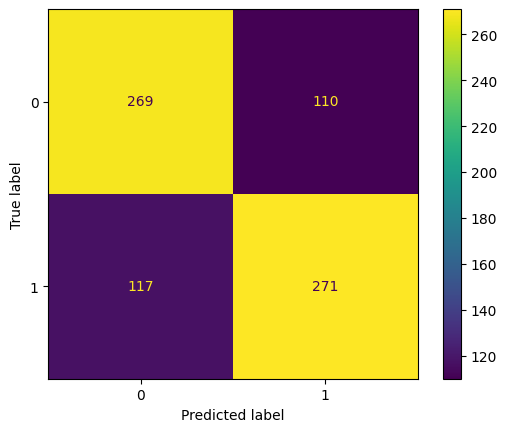

In [27]:
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()

## save the trained model

In [45]:
joblib.dump(rf, "RF.pkl") 

['RF.pkl']